In [1]:
!pip install imbalanced-learn

In [33]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [38]:
from imblearn.over_sampling import SMOTE

In [57]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization, ReLU
from tensorflow.keras.models import Model
print("1")

1


In [58]:
from tensorflow.keras.layers import Input, Conv2D, DepthwiseConv2D

In [42]:
DATA_PATH = "/kaggle/input/datasets/sabahesaraki/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT"

CLASS_NAMES = ["benign", "malignant", "normal"]

IMAGE_SIZE = 128

print(DATA_PATH)

/kaggle/input/datasets/sabahesaraki/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT


In [43]:
def load_ultrasound_dataset(dataset_dir, categories, img_size):

    image_collection = []
    label_collection = []

    for category in categories:

        category_path = os.path.join(dataset_dir, category)

        for file_name in os.listdir(category_path):

            if "_mask" in file_name:
                continue

            file_path = os.path.join(category_path, file_name)

            img = cv2.imread(file_path)
            img = cv2.resize(img, (img_size, img_size))
            img = img.astype("float32") / 255.0

            image_collection.append(img)
            label_collection.append(category)

    images_np = np.array(image_collection)
    labels_np = np.array(label_collection)

    return images_np, labels_np


X, y = load_ultrasound_dataset(DATA_PATH, CLASS_NAMES, IMAGE_SIZE)

print("Dataset size:", X.shape)

Dataset size: (780, 128, 128, 3)


In [44]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Encoded classes:", label_encoder.classes_)

Encoded classes: ['benign' 'malignant' 'normal']


In [45]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    stratify=y_encoded,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (546, 128, 128, 3)
Validation: (117, 128, 128, 3)
Test: (117, 128, 128, 3)


In [61]:
def depthwise_separable(x, filters, strides=(1,1)):

    # Depthwise
    x = DepthwiseConv2D((3,3), strides=strides, padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # Pointwise
    x = Conv2D(filters, (1,1), padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    return x

print("1")

1


In [62]:
def build_model():

    inputs = Input(shape=(128,128,3))

    x = Conv2D(32, (3,3), strides=(2,2), padding='same')(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # Depthwise Separable Blocks
    x = depthwise_separable(x, 64)
    x = depthwise_separable(x, 128, strides=(2,2))
    x = depthwise_separable(x, 128)

    x = depthwise_separable(x, 256, strides=(2,2))
    x = depthwise_separable(x, 256)

    x = depthwise_separable(x, 512, strides=(2,2))

    for _ in range(3):
        x = depthwise_separable(x, 512)

    x = depthwise_separable(x, 1024, strides=(2,2))
    x = depthwise_separable(x, 1024)

    # Classification Head
    x = GlobalAveragePooling2D()(x)

    x = Dense(256, activation="relu")(x)
    x = Dropout(0.5)(x)

    x = Dense(128, activation="relu")(x)
    x = Dropout(0.3)(x)

    outputs = Dense(3, activation="softmax")(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.0001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

print("1")

1


In [63]:
imbalanced_model = build_model()

history_imbalanced = imbalanced_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=16
)

Epoch 1/50


I0000 00:00:1774547679.640158     135 service.cc:152] XLA service 0x7ba6040026e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774547679.640200     135 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1774547682.392219     135 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-26 17:54:49.593643: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-26 17:54:49.793034: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1774547697.964437     135 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the proc

35/35 ━━━━━━━━━━━━━━━━━━━━ 61s 751ms/step - accuracy: 0.4492 - loss: 1.1294 - val_accuracy: 0.2735 - val_loss: 1.0983
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5830 - loss: 0.9549 - val_accuracy: 0.2735 - val_loss: 1.1103
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5628 - loss: 0.9524 - val_accuracy: 0.2735 - val_loss: 1.1432
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6081 - loss: 0.9101 - val_accuracy: 0.2735 - val_loss: 1.1978
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6219 - loss: 0.8755 - val_accuracy: 0.2735 - val_loss: 1.2343
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6255 - loss: 0.8978 - val_accuracy: 0.2735 - val_loss: 1.2727
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6492 - loss: 0.8316 - val_accuracy: 0.2735 - val_loss: 1.3049
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7234 - loss: 0.7614 - val_accuracy: 0.2735 - val_loss: 

## Evaluation Functions

In [64]:
def evaluate_model(model, X_test, y_test):

    preds = model.predict(X_test)
    pred_labels = np.argmax(preds, axis=1)

    acc = accuracy_score(y_test, pred_labels)
    prec = precision_score(y_test, pred_labels, average="weighted")
    rec = recall_score(y_test, pred_labels, average="weighted")
    f1 = f1_score(y_test, pred_labels, average="weighted")

    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)

    print("\nDetailed Report")
    print(classification_report(y_test, pred_labels))

    return acc, prec, rec, f1


print("Results for Imbalanced Training")
acc1, prec1, rec1, f11 = evaluate_model(imbalanced_model, X_test, y_test)

Results for Imbalanced Training
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step
Accuracy: 0.6239316239316239
Precision: 0.6365522067276453
Recall: 0.6239316239316239
F1 Score: 0.6143596358911236

Detailed Report
              precision    recall  f1-score   support

           0       0.66      0.76      0.70        66
           1       0.50      0.52      0.51        31
           2       0.78      0.35      0.48        20

    accuracy                           0.62       117
   macro avg       0.65      0.54      0.56       117
weighted avg       0.64      0.62      0.61       117



## Apply SMOTE for balancig data

In [65]:
X_train_vector = X_train.reshape(len(X_train), -1)

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X_train_vector, y_train)

print("Before balancing:", np.bincount(y_train))
print("After SMOTE:", np.bincount(y_resampled))

X_resampled = X_resampled.reshape(-1, IMAGE_SIZE, IMAGE_SIZE, 3)

Before balancing: [306 147  93]
After SMOTE: [306 306 306]


In [77]:
X_resampled = X_resampled.reshape(-1,128,128,3)

In [78]:
balanced_model = build_model()

history_balanced = balanced_model.fit(
    X_resampled,
    y_resampled,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=16
)

print("Results for SMOTE Balanced Training")
acc2, prec2, rec2, f12 = evaluate_model(balanced_model, X_test, y_test)

Epoch 1/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 54s 452ms/step - accuracy: 0.4244 - loss: 1.0942 - val_accuracy: 0.2735 - val_loss: 1.1859
Epoch 2/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5307 - loss: 0.9212 - val_accuracy: 0.2735 - val_loss: 1.4023
Epoch 3/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5637 - loss: 0.9162 - val_accuracy: 0.2735 - val_loss: 1.6435
Epoch 4/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.5360 - loss: 0.9185 - val_accuracy: 0.2735 - val_loss: 2.0453
Epoch 5/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6164 - loss: 0.8390 - val_accuracy: 0.2735 - val_loss: 2.4260
Epoch 6/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6412 - loss: 0.7824 - val_accuracy: 0.2735 - val_loss: 2.8990
Epoch 7/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6781 - loss: 0.7434 - val_accuracy: 0.2735 - val_loss: 3.4404
Epoch 8/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7980 - loss: 0.5202 - val_accuracy: 0.2735 -

In [82]:
print("\nFinal Performance Comparison")

print("\nImbalanced Model")
print("Accuracy:", acc1)
print("Precision:", prec1)
print("Recall:", rec1)
print("F1 Score:", f11)

print("\nBalanced Model (SMOTE)")
print("Accuracy:", acc2)
print("Precision:", prec2)
print("Recall:", rec2)
print("F1 Score:", f12)


Final Performance Comparison

Imbalanced Model
Accuracy: 0.6239316239316239
Precision: 0.6365522067276453
Recall: 0.6239316239316239
F1 Score: 0.6143596358911236

Balanced Model (SMOTE)
Accuracy: 0.5811965811965812
Precision: 0.5602180541158421
Recall: 0.5811965811965812
F1 Score: 0.5663107114387899


## Visualization

In [85]:
def visualize_predictions(model, X_data, y_true, encoder, num_samples=15):

    random_indices = np.random.choice(len(X_data), num_samples)

    sample_imgs = X_data[random_indices]
    sample_labels = y_true[random_indices]

    preds = model.predict(sample_imgs)
    pred_classes = np.argmax(preds, axis=1)

    plt.figure(figsize=(12,18))

    for i in range(num_samples):

        ax = plt.subplot(5,3,i+1)
        ax.axis("off")

        actual = encoder.classes_[sample_labels[i]]
        predicted = encoder.classes_[pred_classes[i]]

        ax.set_title(f"Actual: {actual}\nPredicted: {predicted}")

        plt.imshow(sample_imgs[i])

    plt.tight_layout()
    plt.show()

## Predictions

Predictions from SMOTE Balanced Model
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


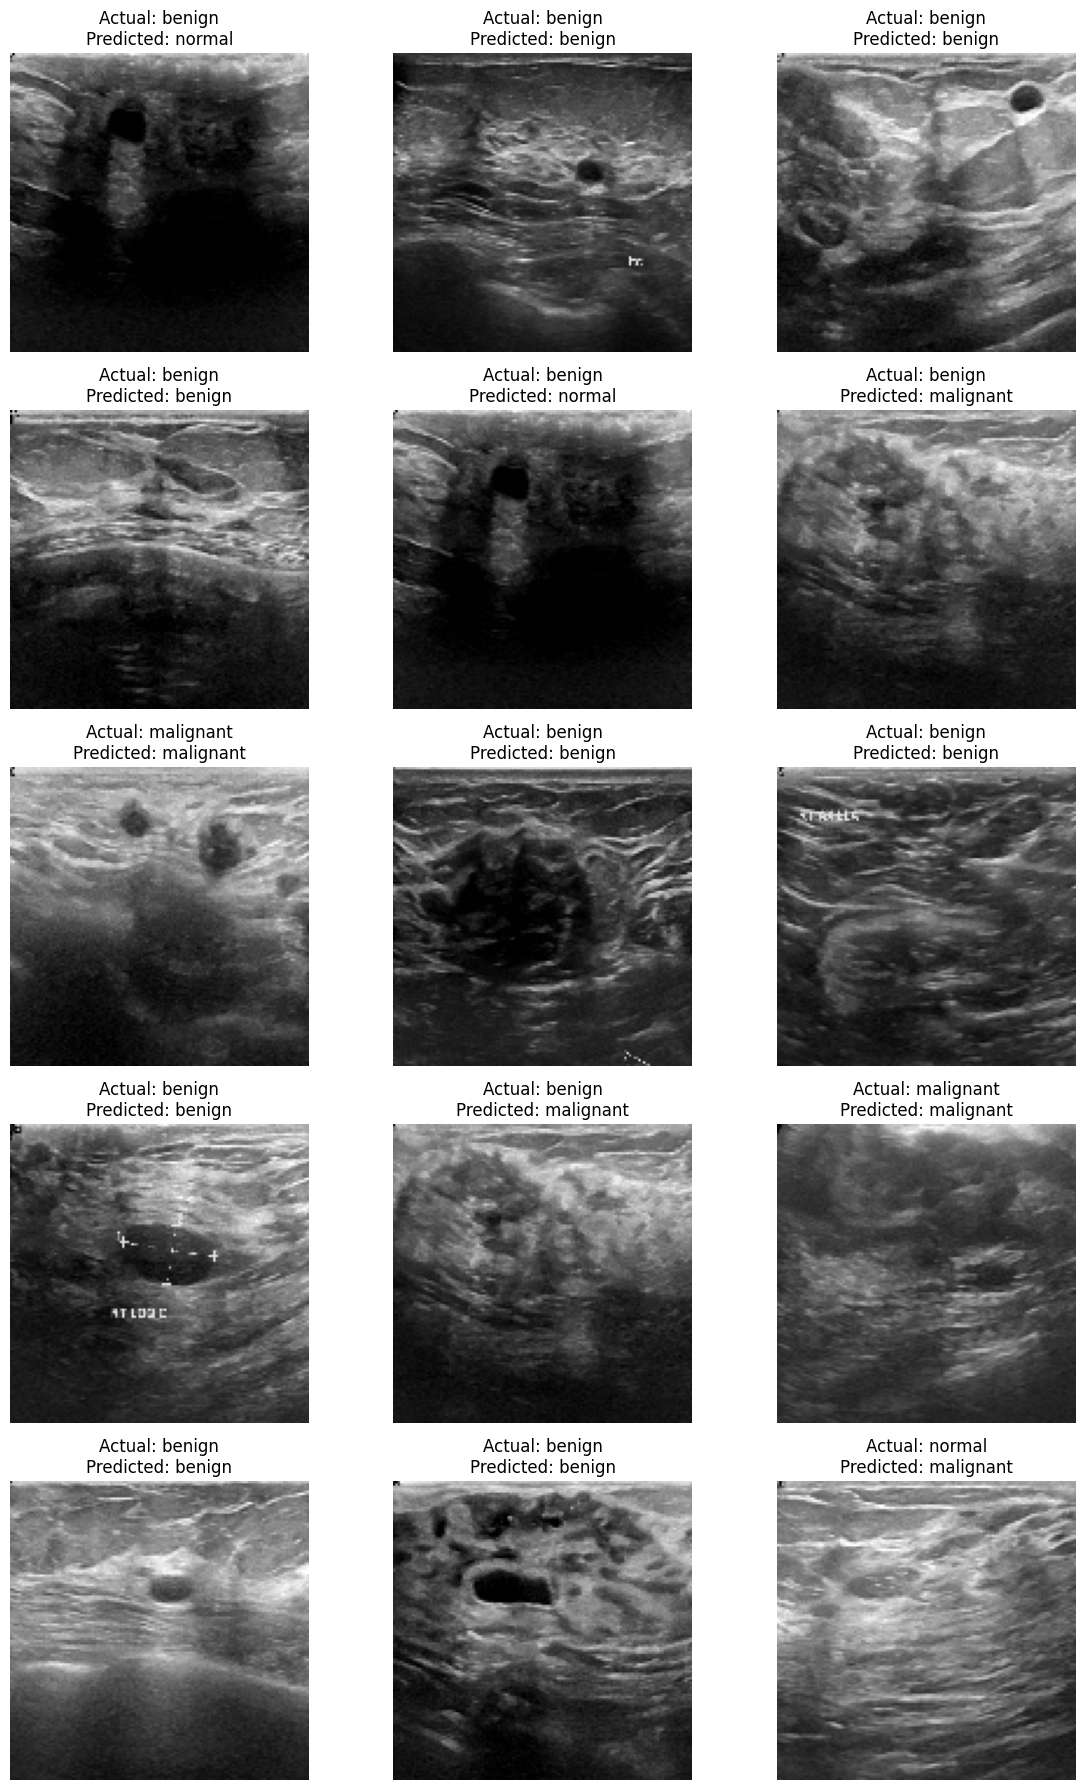

Predictions from Imbalanced Model
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


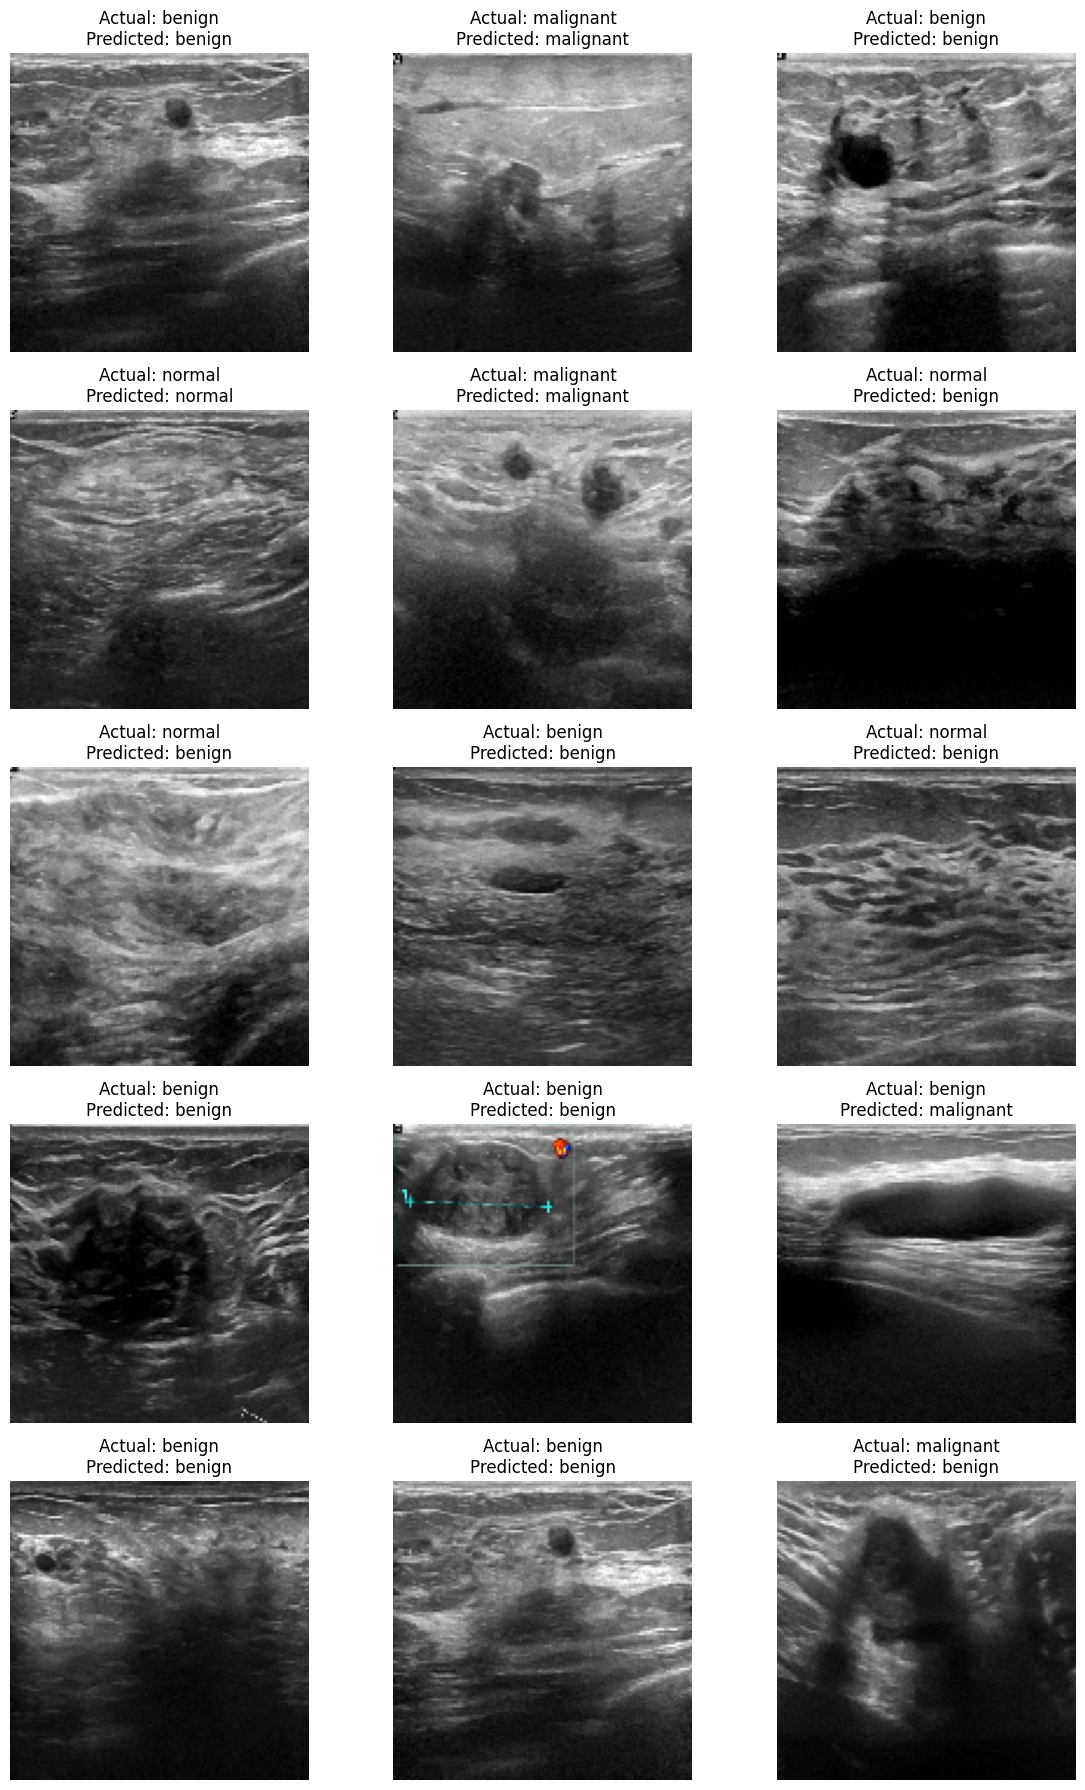

In [86]:
print("Predictions from SMOTE Balanced Model")
visualize_predictions(balanced_model, X_test, y_test, label_encoder)

print("Predictions from Imbalanced Model")
visualize_predictions(imbalanced_model, X_test, y_test, label_encoder)